In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
# Layers are the fundamental units for constructing neural network. They perform computations on input data like pooling etc.
# Models integrate these layers to form a network

In [4]:
# Upload MNIST dataset from Keras Dataset
(x_train, y_train),(x_test, y_test)=tf.keras.datasets.mnist.load_data()

print('x_train shape', x_train.shape)
print('y_train shape', y_train.shape)
print('x_test shape', x_test.shape)
print('y_test shape', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape (60000, 28, 28)
y_train shape (60000,)
x_test shape (10000, 28, 28)
y_test shape (10000,)


In [5]:
# Normalize the pixel values (0-255 to 0-1). Neural network learn faster when values are between 0 and 1
x_train, x_test=x_train/255.0, x_test/255.0

# Adding channel dimension. CNN expects input shape as (batch_size, height, width, channels).
# batch_size- no. of images that we pass through the cnn at once.
# height and width of image
# Channels- colour channels: 1 for grayscale and 3 for RGB
x_train=x_train.reshape(60000, 28, 28, 1)
x_test=x_test.reshape(10000, 28, 28, 1)

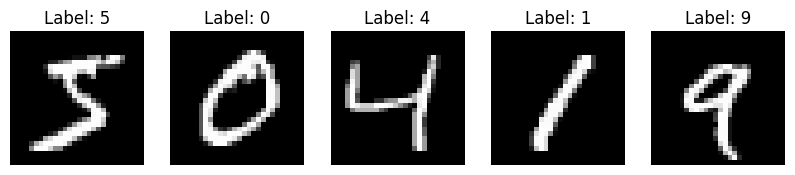

In [6]:
# Display the first 5 training images
plt.figure(figsize=(10,4))
for i in range(5):
  plt.subplot(1,5,i+1) # Creates a subplot with 1 row and 5 columns and display the i+1 image
  plt.imshow(x_train[i].reshape(28,28), cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

In [10]:
# Create the CNN Model
model=models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)), # This is the Convolutional Layer. It extracts features like curves and edges using 32 filters, each of size 3x3. Relu is used to add non-linearity.
    layers.MaxPooling2D(2,2), # It is used to reduce the size of filters to 2x2 and extracts only the important features.

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(), # Converts 2D feature map into 1D
    layers.Dense(64, activation='relu'), # Dense refers to the fully connected layer. Each neuron connected to every previous neuron. Calculates weighted sum of inputs+bias and apply activation function. If value positive, then keep it else output 0.
    layers.Dense(10, activation='softmax') # Softmax ensures that output is a probability distribution.
])

In [11]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Optimizer adjusts the learning rate while training
# Loss calculates the difference between the actual and the predicted values or predictions
# metrics is used to evaluate the model's performance during training

In [12]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.9045 - loss: 0.3209 - val_accuracy: 0.9845 - val_loss: 0.0449
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.9852 - loss: 0.0471 - val_accuracy: 0.9889 - val_loss: 0.0343
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9903 - loss: 0.0305 - val_accuracy: 0.9912 - val_loss: 0.0281
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.9909 - val_loss: 0.0305
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9898 - val_loss: 0.0327
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 28ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.9922 - val_loss: 0.0271
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.9972 - loss: 0.0092 - val_accuracy: 0.9912 - val_loss: 0.0253
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9976 -

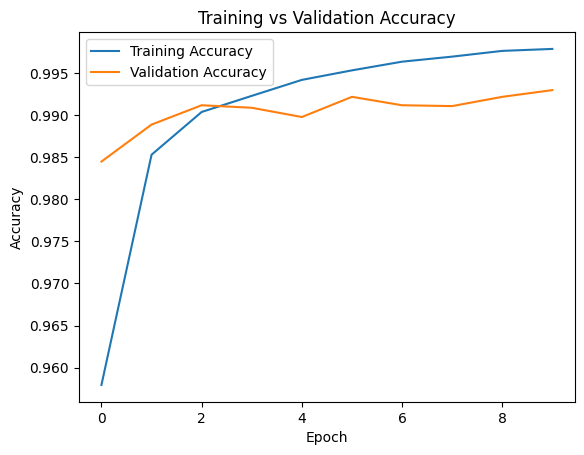

In [13]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [15]:
# Evaluate model performance
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)


313/313 - 2s - 8ms/step - accuracy: 0.9930 - loss: 0.0377

Test accuracy: 0.9929999709129333


In [17]:
# Save the trained model
model.save('mnist_cnn_model.keras')